# Rekommendationer

Jag rekommenderar den tunede Random Forest-modellen med n_estimators=300 som beslutssöd för att förutspå huspriserna i ett område.

Modellen förklarar 81% av variationen i bostadspriserna (R2=0.81) och missar i snitt med $32,000 per område (MAE). Test-RMSE på $49,500 ligger i linje med CV-RMSE ($50,000) vilket bekräftar att modellen beter sig stabilt även på ny data och overfittar inte.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score, cross_validate
from sklearn.dummy import DummyRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.set_printoptions(precision=3, suppress=True)


In [2]:
df = pd.read_csv("housing.csv")
target_column_name = "median_house_value"
feature_column_names = [col for col in df.columns if col != target_column_name]

X_full = df[feature_column_names]
y_full = df[target_column_name]

display(df.head())
# Noterar att ocean_proximity inte är numerisk.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# EDA

Datasetet innehåller 20 640 rader och 10 kolumner. Varje rad representerar ett område i Kalifornien.

Nio av kolumnerna är numeriska och en (ocean_proximity) är kategorisk. Av kategoriska värdena finns det ett som enbart finns med i 5 rader (ISLAND). Med så lite träningsdata så kan det bli vansligt att försöka få en modell som förutsäger ö-läge pålitligt. 

Endast kolumnen total_bedrooms har saknade värden (207 stycken missing values). Dessa kommer hanteras med median-imputation i pipeline.

Heatmappen visar på korrelation mellan flera variablerna. För vår target median_house_value, så är den starkaste korrekationen med median_income. (Dock är det viktigt att reflektera över att hushållsinkomst och huspriser är olika sidor av samma mynt och påverkar hur välbärgat ett område är. Se nedan för vidare analys kring faktorer som påverkar target.)

Histogrammet visar att distributionen är sne och att det finns outliners kring $500,000. Det kan finnas flera användingar till det, tex:

- det finns områden med många hus kring en halv miljon dollar

- datan hanterar alla hus på en halv mijon eller över som just $500,000. Dvs, det finns hus värda mer än $500,000 i datasettet men vi ser inte dem



In [3]:
print("Missing values i hela datasetet:")
print(df.isna().sum())

Missing values i hela datasetet:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [4]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [5]:
# Istället för att hard coda vilka kolumner som är kategoriska och vilka som är numeriska, så kan panda sköta detta automatiskt
# vilket är användbart om nya kolumner läggs till till vårt dataset 

numeric_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(include=["str"]).columns.tolist()

print("Nummeriska kolumner:", numeric_features)
print("Kategoriska kolumner:", categorical_features)

Nummeriska kolumner: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Kategoriska kolumner: ['ocean_proximity']


In [6]:
# Kategorisk sammanfattning
print("Kategorisk sammanfattning:")
for col in categorical_features:
    print(f"\n{col}:")
    print(df[col].value_counts())

Kategorisk sammanfattning:

ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


In [8]:
# Titta närmare på target
print("Sammanfattning av target (median_house_value):")
print(f"  Medelvärde:  ${y_full.mean():,.0f}")
print(f"  Median:      ${y_full.median():,.0f}")
print(f"  Std:         ${y_full.std():,.0f}")
print(f"  Min:         ${y_full.min():,.0f}")
print(f"  Max:         ${y_full.max():,.0f}")
print(f"  25%-percentil: ${y_full.quantile(0.25):,.0f}")
print(f"  75%-percentil: ${y_full.quantile(0.75):,.0f}")

Sammanfattning av target (median_house_value):
  Medelvärde:  $206,856
  Median:      $179,700
  Std:         $115,396
  Min:         $14,999
  Max:         $500,001
  25%-percentil: $119,600
  75%-percentil: $264,725


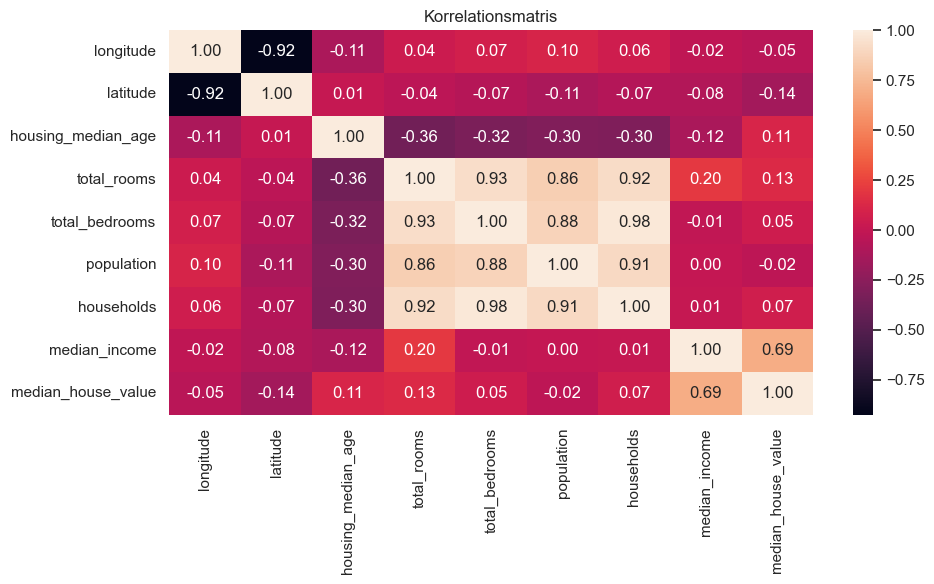

In [9]:
#Heatmap, från Regression videon, Omniway, Vecka 1, https://ec.omniway.se/exam/57484101

correlation_matrix = df.corr(numeric_only=True) #numeric_only=True för att exkludera ocean_proximity

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", ax=ax)
ax.set_title("Korrelationsmatris")
plt.tight_layout()
plt.show()

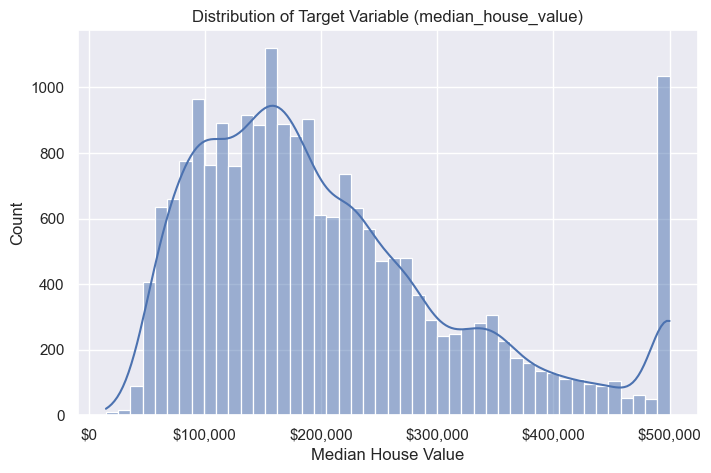

In [10]:
#Distributionsgraf, från Regression videon, Omniway, Vecka 1, https://ec.omniway.se/exam/57484101


plt.figure(figsize=(8, 5))
sns.histplot(y_full, kde=True)
plt.title("Distribution of Target Variable (median_house_value)")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))    #För att öka x-axelns läsbarhet
plt.show()

# Split & prepossession

In [11]:
X_full = df[feature_column_names]
y_full = df[target_column_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42        # reproducerbarhet
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


In [12]:
def add_features(X):
    X = X.copy()
    X["rooms_per_household"]      = X["total_rooms"]    / X["households"]
    X["bedrooms_per_room"]        = X["total_bedrooms"] / X["total_rooms"]
    X["population_per_household"] = X["population"]     / X["households"]
    return X

X_train = add_features(X_train)
X_test  = add_features(X_test)

In [13]:
numeric_features     = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["str"]).columns.tolist()

print("Numeriska värden:", numeric_features)
print("Kategoriska värden:", categorical_features)

Numeriska värden: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Kategoriska värden: ['ocean_proximity']


In [14]:
# Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(           #OneHotEncoder för att hantera kategoriska data
                                            # så att 
                                            # ocean_proximity_<1H OCEAN    = 1 eller 0
                                            # ocean_proximity_INLAND       = 1 eller 0
                                            # ocean_proximity_NEAR OCEAN   = 1 eller 0
                                            # ocean_proximity_NEAR BAY     = 1 eller 0
                                            # ocean_proximity_ISLAND       = 1 eller 0
                                            
        handle_unknown="ignore",        #ignorerar om ny, okänd data kommer i testdatan
        sparse_output=False             #sparse för att det låter bra :)
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

### Baseline

In [15]:

def evaluate_regression(y_true, y_pred, model_name="Model") -> dict:
    # TODO: implementera
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### Pipeline

In [16]:
# baseline = DummyRegressor(strategy="median")
# väljer median istället för mean då vi har stora outliers
baseline_pipeline = Pipeline(steps = [
    ("preprocessor", preprocess),
    ("model", DummyRegressor(strategy = "median"))
])

# fit baseline
baseline_pipeline.fit(X_train, y_train)

# predict (y_pred_base = baseline.predict())
baseline_predictions_test = baseline_pipeline.predict(X_test)

# evaluate_regression()
baseline_results = evaluate_regression(
    y_true = y_test,
    y_pred = baseline_predictions_test,
    model_name = "Baseline (median)"
)

baseline_results


{'Model': 'Baseline (median)',
 'MAE': 87403.99224806202,
 'RMSE': 117311.67105035602,
 'R2': -0.05020862899620537}

### Träna modeller

In [ ]:
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(random_state=42)

pipe_lr = Pipeline([("preprocessor", preprocess), ("model", lr)])
pipe_rf = Pipeline([("preprocessor", preprocess), ("model", rf)])
pipe_gb = Pipeline([("preprocessor", preprocess), ("model", gb)])

### Utvärdera med hjälp av CV

In [18]:
# utvärderar modellerna med hjälp av cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for pipe, name in [(baseline_pipeline, "Baseline (median)"), 
                   (pipe_lr, "Linear Regression"),
                   (pipe_rf, "Random Forest"),
                   (pipe_gb, "Gradient Boosting")]:
    scores = cross_validate(
        pipe, X_train, y_train,
        scoring = {
            "rmse": "neg_root_mean_squared_error",
            "mae":  "neg_mean_absolute_error",
            "r2":   "r2"
        },
        cv=cv,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV RMSE (mean)": -scores["test_mae"].mean(),
        "CV RMSE (std)":  scores["test_mae"].std(),
        "CV MAE (mean)":  -scores["test_mae"].mean(),
        "CV R2 (mean)":    scores["test_r2"].mean(),
    })

cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values("CV RMSE (mean)")  # sortera på lägst RMSE överst
display(cv_df)

best_model_name = cv_df.iloc[0]["Model"]
print("Bästa modell enligt CV:", best_model_name)

,Model,CV RMSE (mean),CV RMSE (std),CV MAE (mean),CV R2 (mean)
2,Random Forest,32911.448726,517.018240,32911.448726,0.810684
3,Gradient Boosting,36605.981311,555.586541,36605.981311,0.791027
1,Linear Regression,48879.908801,982.348302,48879.908801,0.655237
0,Baseline (median),88596.593922,923.332312,88596.593922,-0.055714


Bästa modell enligt CV: Random Forest


# Modellutvärdering

Dummy Regression preseterade sämre än att bara gissa medelvärdet och fångar inget mönster i datan.

Linear Regression är bättre än baseline. Modellen förklarar 66% av variationen i huspriserna men snittar ändå fel på $49,000 för median_house_value i ett område. Och med ett medianvärde på $180,000 så motsvarar ett fel på $49,000 över 25% av husetpriset! Det kan inte anses vara tillförlitligt. 

Random Forest har högst R2 av de fyra modellerna och kan förklara 81% av variationerna i datan. Det huspris medianvärde den förutspår är i snitt fel på $33,000.

Gradient Boosting presterar lite sämre än Random Forest. Dock kanske vi skulle kunna få modellen att presetera bättre med ytterligare tuning. 

Baserat på RMSE som rankningsvertyg (då vi har outliners och RMSE straffar stora fel hårdare än MAE) så kommer Random Forest högst på listan från vår CV utvärdering, och vi gör valet att förstätta med Random Forest som modell. 

### Modelloptimering

In [19]:
print("Vi tunar:", best_model_name)

Vi tunar: Random Forest


In [20]:
# färsk pipeline för att undvika att tidigare träning påverkar
pipe_rf_tuning = Pipeline([
    ("preprocessor", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Hyperparameter grid
param_grid = {
    "model__n_estimators":  [200, 300],
    "model__max_depth":     [None, 10, 20],
    "model__min_samples_split": [2, 5],
}

# Grid search med neg root mean squared error som scoring
grid_search = GridSearchCV(
    pipe_rf_tuning,
    param_grid,
    cv=cv,  
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


# Bäst parameters och score
print("Bäst hyperparametrar:", grid_search.best_params_)
print("Bäst CV RMSE:", -grid_search.best_score_)

Bäst hyperparametrar: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Bäst CV RMSE: 50112.07216432915


# Hyperparameter-tuning

Efter att ha valt att gå vidare med Random Forest har vi hyperparameter tunat. Med outliers i datan så fokuserar vi på RMSE (neg_root_mean_squared_error) som scoring metric.

Vi har testat med GridSearchCV (5 fold) med följande hyperparametrar:
- `n_estimators` [200, 300] – antal träd i skogen, fler träd ger stabilare förutsägelser men tar längre tid att träna. Började med 100 och 200. Testade sen 200 och 300 och fick 300 som bäst optimering.
- `max_depth` [None, 10, 20] – hur djupa träden får växa, begränsar 
  overfitting
- `min_samples_split` [2, 5] – minsta antal samples för att dela en nod, 
  också för att begränsa overfitting

Från vår optimering fick vi de bästa parametrar:

n_estimators = 300

max_depth = None (vilket är default för Random Forest, så egentligen ingen tuning)

min_samples_split = 2 (också default)

Att max_depth och min_samples_split landade på defaultvärden tyder på att Random Forest inte behöver extra regularisering på den här datan. Modellen generaliserar redan bra utan begränsningar.


In [21]:
# Kör modellen på testdatan
best_model = grid_search.best_estimator_

y_pred_test = best_model.predict(X_test)

final_results = evaluate_regression(
    y_true=y_test,
    y_pred=y_pred_test,
    model_name="Random Forest (tunad)"
)

print(final_results)

{'Model': 'Random Forest (tunad)', 'MAE': 31774.224513081394, 'RMSE': 49447.35683328401, 'R2': 0.8134138930366339}


# Utvärding på test-datan

När vi kör den tunade modellen på testdatan så visar den 81% av variationerna i datan fångas upp av modellen. I snitt förutspår modellen huspriser som ligger cirka $32,000 från det faktiska värdet, vilket modsvara ungefär 17% mot medianvärdet på $180,000.

Om man jämför hur modellen fungerade på testdatan mot träningsdatan, så ser vi att ett RMSE på $49,500 är något bättre än vi fick på träningsdatan ($50,100). 




In [37]:
# Undersöka faktorer som påverkar huspriser

rf_model = best_model.named_steps["model"]
feature_names = (
    numeric_features +
    list(best_model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(categorical_features))
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(10))


,Feature,Importance
7,median_income,0.480859
12,ocean_proximity_INLAND,0.138620
10,population_per_household,0.120942
0,longitude,0.057775
1,latitude,0.056684
2,housing_median_age,0.044080
8,rooms_per_household,0.026080
9,bedrooms_per_room,0.024374
3,total_rooms,0.012639
4,total_bedrooms,0.011951


In [42]:
df_with_features["population_per_household"].describe()

count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: population_per_household, dtype: float64

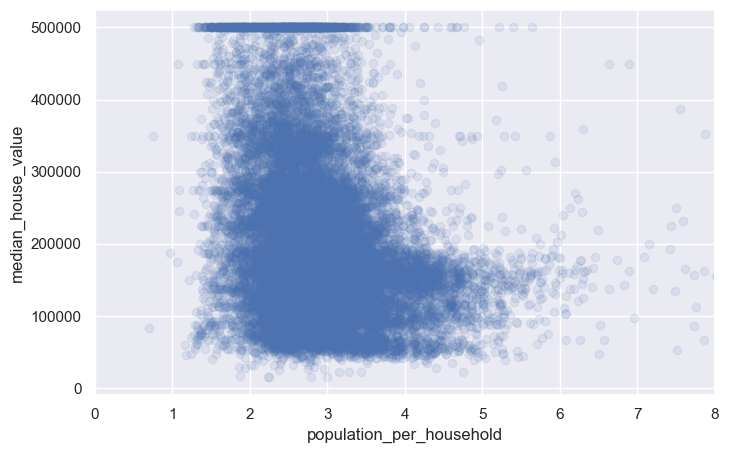

In [43]:
# titta närmare på population_per_household och median_house_value

plt.figure(figsize=(8, 5))
plt.scatter(df_with_features["population_per_household"], 
            df_with_features["median_house_value"], alpha=0.1)
plt.xlabel("population_per_household")
plt.ylabel("median_house_value")
plt.xlim(0, 8)  # pga outliers begränsar jag x-axeln 
plt.show()

# Faktorer som påverkar huspriser i ett område

När vi tittar på vilka faktorer som påverkar hur modellen förutspår huspriserna mest, så är median_income är den enskilt viktigaste faktorn 
(48%). Detta kunde vi utläsa redan från rådatan och som vi redan konstaterat så finns det ett cirkelargument i detta - hushållsinkomst och huspriser mäter till stor del samma sak. Invidider med hög inkomst kan köpa dyra hus och på så sätt flytta in i höginkomstområden. 

Andra faktorer som bidrar är strandnära placering (förklarar 14% av hur modellen förutspår huspriser) och antalet personer i hushållet (12%). Här gissade vi att områden med högre antal personer i hushållet är associerat med områden med lägre huspriser, då trångboddhet ofta är associerat med lägre hushållsinkomst. För att vara säkra gjorde vi en scatterplot för att undersöka förhållandet och såg att högre antal personer per hushåll är associerat med lägre huspriser, så det bekräftar vår teori. 

# Undersöker om datan verkar innehålla struktur genom att använda KMeans (oövervakad inlärning)

När jag tittar på elbow kurvan verkar K=3 vara bäst val men jag får högst silhouette på K=2. Jag tänker dock att enbart två kluser är något onyanserat och då elbow kurvan ändå visar på att det finns underlag för tre kluster så prövar jag att gå vidare och undersöka det. Häri finns även en av osäkerheterna kring Kmeans - jag måste manuellt välja ett K och det finns inget tydligt rätt eller fel. Jag är också medveten om att modellen alltid kommer att hitta mönster i datan och att det är upp till mig att utvärdera om de är användbara kluster eller inte. 

För modellen inkluderade jag alla numeriska X-variabler (exklusive median_house_value som är target) samt de tre feature engineering-variablerna. ocean_proximity exkluderas eftersom KMeans kräver numeriska värden. Alla features standardiseras med StandardScaler. 

De tre klustren som modellen finner i datan visar sig vara geografiska. När man ritar ut dem på en karta blir det dock tydligt att det finns ett nordligt och ett sydligt kluster, medan det tredje klustret som modellen identifierar täcker bägge regionerna. Det kan möjligtvis representera storstadsregioner. 

Klustren skulle kunna användas för att segmentera marknaden regionalt och på så sätt vara ett beslutsstöd för investeringar. Dock är klustren så grovt indelade (tre kluster för hela Kalifornien) att jag har svårt att se att en sådan modell skulle vara till nytta för några slags reella byggbeslut. 

In [24]:
# Välj features för klustring (endast numeriska)
df_with_features = add_features(df)
X_cluster = df_with_features.select_dtypes(include=["number"]).drop(columns=["median_house_value"]).copy()


# Hantera missing values
X_cluster = X_cluster.fillna(X_cluster.median())

# Skala datan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# PCA för visualisering
pca = PCA(n_components=2)
X_pca_2 = pca.fit_transform(X_scaled)

print("X_scaled shape:", X_scaled.shape)
print("X_pca_2 shape:", X_pca_2.shape)

X_scaled shape: (20640, 11)
X_pca_2 shape: (20640, 2)


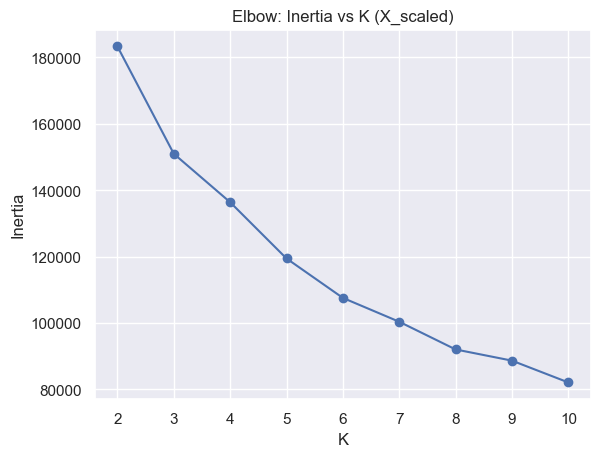

In [25]:
# för att hitta elbow. https://ec.omniway.se/exam/58034391
inertias = []
K_range = range(2, 11)

for K in K_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow: Inertia vs K (X_scaled)")
plt.grid(True)
plt.show()

,K,inertia,silhouette
0,2,183318.661199,0.386848
1,3,150995.263709,0.269998
2,4,136397.407446,0.241324
3,5,119450.057789,0.240839
4,6,107573.553980,0.248883
5,7,100387.999939,0.219619
6,8,92047.915971,0.209136
7,9,88676.075921,0.203829
8,10,82107.221467,0.198657


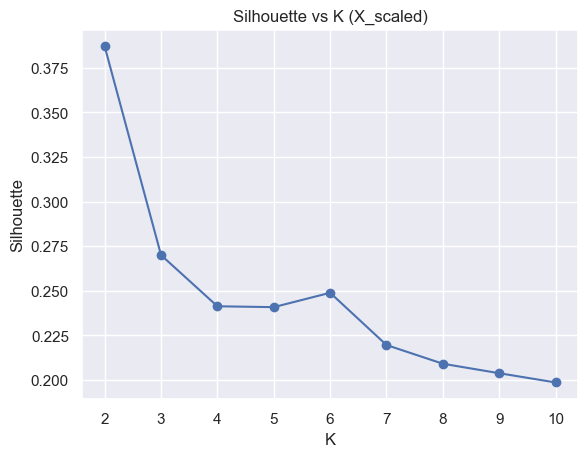

In [26]:
results = []

for K in range(2, 11):
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append({ "K": K, "inertia": km.inertia_, "silhouette": sil })

results_df = pd.DataFrame(results)
display(results_df)

plt.figure()
plt.plot(results_df["K"], results_df["silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.title("Silhouette vs K (X_scaled)")
plt.grid(True)
plt.show()

In [27]:
K_final = 3
kmeans_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(pd.Series(cluster_labels).value_counts().sort_index())

0    10803
1     8122
2     1715
Name: count, dtype: int64


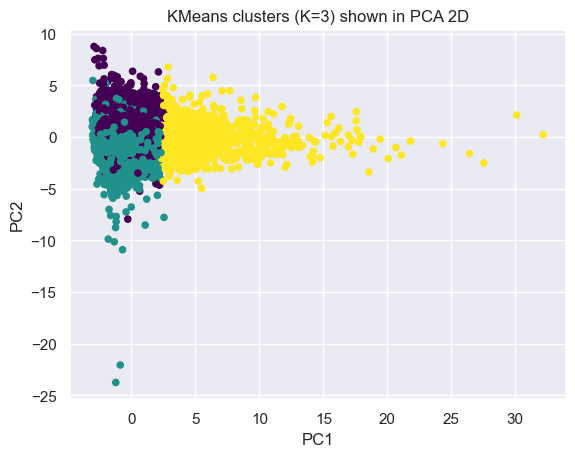

In [33]:
plt.figure()
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=cluster_labels, cmap="viridis", s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (K=3) shown in PCA 2D")
plt.grid(True)
plt.show()

In [36]:
# vad betyder klustren
df_with_features.groupby("cluster")[["median_house_value", "median_income", 
                                      "latitude", "longitude",
                                      "rooms_per_household", 
                                      "population_per_household"]].mean()

,median_house_value,median_income,latitude,longitude,rooms_per_household,population_per_household
cluster,,,,,,
0,212691.266685,3.877087,33.941853,-118.022853,5.186286,3.081926
1,195914.680005,3.785783,37.961118,-121.715164,5.721293,3.111378
2,221913.280466,4.232271,35.246402,-119.152921,5.573626,2.806802


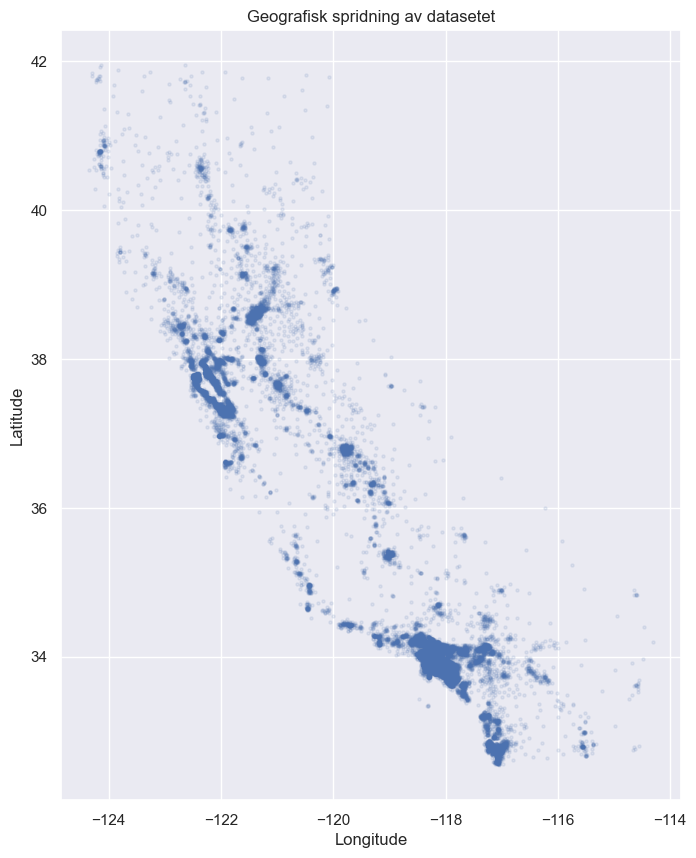

In [47]:
# ritar ut all data enligt lat och long 
plt.figure(figsize=(8, 10))
plt.scatter(df['longitude'], df['latitude'], alpha=0.1, s=5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geografisk spridning av datasetet")
plt.grid(True)
plt.show()

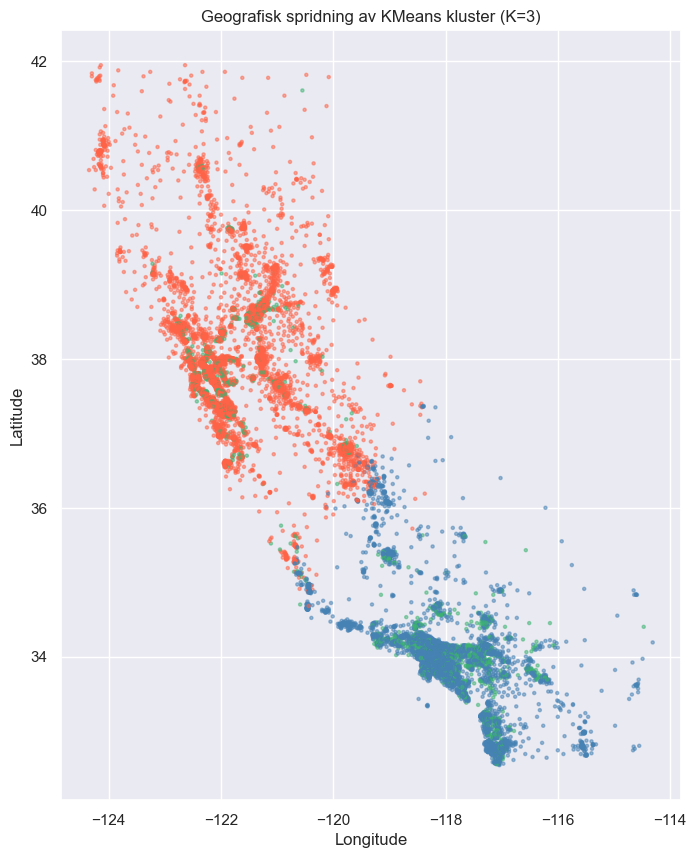

In [48]:
# ritar ut klustren enligt lat och long

colors = {0: "steelblue", 1: "tomato", 2: "mediumseagreen"}
c = [colors[label] for label in cluster_labels]

plt.figure(figsize=(8, 10))
plt.scatter(df_with_features['longitude'], df_with_features['latitude'], 
            c=c, s=5, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geografisk spridning av KMeans kluster (K=3)")
plt.grid(True)
plt.show()